In [1]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu

from train_mod_cog import RNNModel

device = eg_utils.get_device()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


['/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf']
/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf
/home/mila/p/pingsheng.li/projects/eg_rnns/mod_cog/analysis/arial.ttf


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined") # 
results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd")

os.listdir(results_dir)

['eg_unsigned_N2500_lr1.0_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-06_mxg

In [4]:
scratch = Path(os.environ["SCRATCH"])
scratch

PosixPath('/network/scratch/p/pingsheng.li')

In [5]:
run_results_dir = scratch/"eg_paper/mod_cog/sign_constrained_gd"
os.listdir(run_results_dir)

['gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss']

In [6]:
from pathlib import Path
import shutil

dst = Path("/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd")
src = run_results_dir

# Ensure destination exists
dst.mkdir(parents=True, exist_ok=True)

# Copy each item in source into destination
for item in src.iterdir():
    target = dst / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)  # Python 3.8+
    else:
        shutil.copy2(item, target)  # copies file with metadata

In [7]:
csgd_results_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd")
exp_names = os.listdir(csgd_results_dir)
exp_names

['eg_unsigned_N2500_lr1.0_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr1.0_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-05_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'eg_unsigned_N2500_lr3.5_m0.925_wd1e-06_mxg

In [8]:
os.listdir(csgd_results_dir/exp_names[0]/"seed_6")

['dec_acc_ckpts',
 'eval_results.npy',
 'train_results.npy',
 'epoch_ckpts',
 'config.yaml']

In [9]:
# here repeat fig1a stuff

def format_exp_as_key(exp_name):
    if exp_name.startswith("eg_unsigned"):
        s = "eg_unsigned"
    elif exp_name.startswith("cgd"):
        s = "cgd"
    else:
        s = exp_name[:2]
    if "log_normal" in exp_name:
        s += "_log_normal"
    elif "normal" in exp_name:
        s += "_normal"
    elif "uniform" in exp_name:
        s += "_uniform"
    return s

exp_folders = au.DotDict({format_exp_as_key(f):csgd_results_dir/f for f in exp_names})
results_dict = au.load_results(exp_folders)
# Stack results across all seeds for each experiment
for exp_name in results_dict.keys():
    print(exp_name)
    results_dict[exp_name] = au.concat_seed_results(results_dict[exp_name])



eg_unsigned_log_normal
eg_unsigned_uniform
gd_normal
gd_uniform
eg_unsigned_normal
gd_log_normal
eg_uniform
eg_log_normal
cgd_log_normal
eg_normal


In [11]:
results_dict.cgd_log_normal.c = "#0c8827" # green

0.9742835402488709 0.0014460740781236246 (6000, 5)


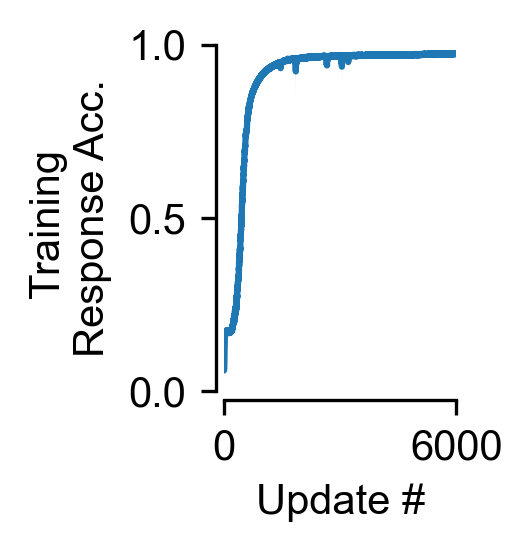

In [10]:
exp_strs = ["cgd_log_normal"]
key = "Dec Acc"
xlims = (0, 6000)
ylims = (0, 1)

plt.figure(figsize=(1.,1.5), dpi = 300)
for exp_name in exp_strs:
    array = results_dict[exp_name].train_results[key].mean(axis=1)
    std_dev = results_dict[exp_name].train_results[key].std(axis=1)
    print(array[-1], std_dev[-1], results_dict[exp_name].train_results[key].shape)
    n_updates = array.shape[0]
    plt.plot(np.arange(1,n_updates+1), array, c=results_dict[exp_name].c, label=exp_name)
    plt.fill_between(np.arange(1,n_updates+1), array-std_dev, array+std_dev, color=results_dict[exp_name].c, alpha=0.2)
ax = plt.gca()

# Set the tick locations
logx = False
logy = False
if logx: plt.xscale("log")
if logy: plt.yscale("log")

y_step = 0.5
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
ax.set_yticks(np.arange(ylims[0],ylims[1]+y_step, y_step)) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

# sns.despine(offset=2, trim=True)

plt.xlabel("Update #")
plt.ylabel("Training \nResponse Acc.", rotation=90)

#sns.despine()
sns.despine(offset=2, trim=True)

# plt.tight_layout()
#plt.savefig("figs/fig1/1c_response_acc.pdf", bbox_inches="tight", transparent=True)

(5,)
0.9838015948534011 5.8444066712415734e-05


ValueError: Invalid RGBA argument: None

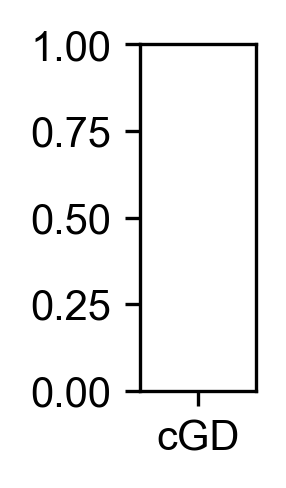

In [11]:
plt.figure(figsize=(0.5,1.5), dpi = 300)
exp_labels = ["cGD"]#, "EG"]
colours = [results_dict[exp_str].c for exp_str in exp_strs]
key = "test_Dec_Acc"
means = []
std_devs = []
for exp_name in exp_strs:
    array = results_dict[exp_name].eval_results[key][-1,:] # last epoch, all seeds
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3, width=0.8)
sns.despine(offset=2)

plt.ylabel("Test \nResponse Acc.")

#plt.savefig("figs/fig1/1c_response_acc_test.pdf", bbox_inches="tight", transparent=True)

In [ ]:
# gd_results = results_dict.gd_log_normal
# eg_results = results_dict.eg_log_normal

# eg = eg_results.train_results["rnn.weight_hh"]['r2']
# gd = gd_results.train_results["rnn.weight_hh"]['r2']



In [12]:
csgd_results = results_dict.cgd_log_normal

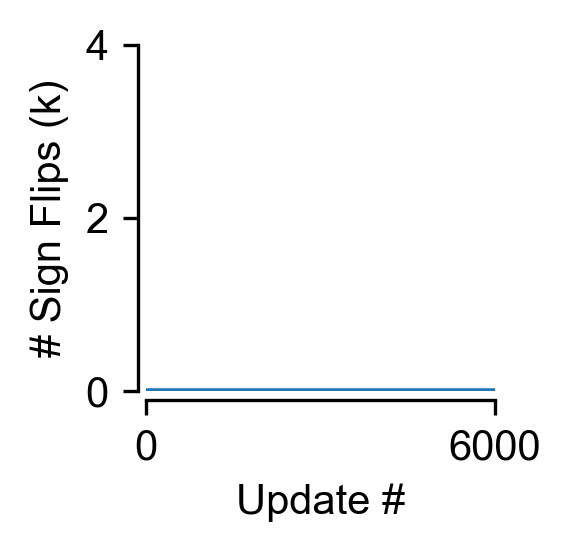

In [13]:
gd = csgd_results.train_results["rnn.weight_hh_sflips"]

plt.figure(figsize=(1.5,1.5), dpi = 300)

# plt.plot(np.nanmean(eg, axis=1), color=eg_results.c, label='EG')
# plt.fill_between(np.arange(eg.shape[0]), 
#                     np.nanmean(eg, axis=1) - np.nanstd(eg, axis=1),
#                     np.nanmean(eg, axis=1) + np.nanstd(eg, axis=1),
#                     color=eg_results.c, alpha=0.5)

plt.plot(np.nanmean(gd, axis=1), color=csgd_results.c, label='GD')
plt.fill_between(np.arange(gd.shape[0]), 
                    np.nanmean(gd, axis=1) - np.nanstd(gd, axis=1),
                    np.nanmean(gd, axis=1) + np.nanstd(gd, axis=1),
                    color=csgd_results.c, alpha=0.5)

plt.ylabel('# Sign Flips (k)')
plt.xlabel('Update #')  

ax = plt.gca()
xlims = (0, 6000)
ylims = (0, 4000)
y_step = 2000
x_step = 6000
ax.set_xticks(np.arange(xlims[0],xlims[1]+x_step, x_step))  
yticks = np.arange(ylims[0],ylims[1]+y_step, y_step)
ylabels = [int(int(s)/1000) for s in yticks]
ax.set_yticks(yticks, labels=ylabels) 
ax.set_xlim(xlims)
ax.set_ylim(ylims)

sns.despine(offset=2, trim=True)

In [14]:
from scipy.stats import norm

def get_norm_pdf(points, mean, std):
    return norm(loc=mean, scale=std).pdf(points)

def get_checkpoint_name(results, seed, epoch_idx):
    return str(results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt'


def plot_weight_hists(cgd_exp_results, cgd_key, epoch_idx=6,
                      zero_th=None, log_weights=False, log_y_scale=False, kde=False, stat='proportion',
                     gaussian_approx=False, seperate_plots=True, xlims_step=None, ylims_step=None, 
                      figsize_tuple=None, axis_off=False):
    print("Todo: suppress / correct warnings!")
    if figsize_tuple is None: 
        figsize_tuple = (1.5,1.5)
    # fig = plt.figure(figsize=figsize_tuple, dpi = 300)
    cgd_arr_all = []
    for seed in ["seed_5","seed_6","seed_7","seed_8","seed_9"]:
        fig = plt.figure(figsize=figsize_tuple, dpi = 300)
        #plt.title(seed)
        print(type(fig))
        if seperate_plots:
            # Add an axes to the figure at position [left, bottom, width, height]
            # ax_eg = fig.add_axes([0.1, 0.1, 0.4, 1])
            # ax_gd = fig.add_axes([0.6, 0.1, 0.4, 1])
            ax_cgd = fig.add_axes([0.0, 0.5, 0.8, .4])
        else:
            ax_eg = fig.add_subplot(111)
            ax_gd = ax_eg

        cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),
                             map_location=torch.device('cpu'))
        print(str(cgd_exp_results[seed].epoch_ckpts[0]).split('model_')[0] + f'model_{epoch_idx}.pt')
        
        cgd_key = cgd_key

        cgd_arr = cgd_ckpt[cgd_key].flatten().detach().numpy()

        cgd_arr = np.abs(cgd_arr)
        
        if zero_th is not None:
            cgd_arr = cgd_arr[cgd_arr > zero_th]
        if log_weights:
            cgd_arr = np.log(cgd_arr)
    #     gd_arr = np.where(np.isinf(gd_arr), np.nan, gd_arr)
    #     eg_arr = np.where(np.isinf(eg_arr), np.nan, eg_arr)

#         print(f"GD: std {np.std(gd_arr)}, skew {stats.skew(gd_arr)}, kurtosis  {stats.kurtosis(gd_arr)}")
#         print(f"EG: std {np.std(eg_arr)}, skew {stats.skew(eg_arr)}, kurtosis  {stats.kurtosis(eg_arr)}")
        max_weight = np.max([np.max(cgd_arr)])
        bin_edges = np.linspace(min(0, np.min([np.min(cgd_arr)])), max_weight, 50)

        sns.histplot(cgd_arr, bins = bin_edges, kde=kde, stat=stat, color=cgd_exp_results.c, ec=None,
                    label='cSGD', ax=ax_cgd)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(cgd_arr)])), max_weight, 500)
            ax_cgd.plot(points, get_norm_pdf(points, cgd_arr.mean(), cgd_arr.std()), color=cgd_exp_results.c,
                    linestyle='--')
        
        sns.histplot(cgd_arr, bins = bin_edges, kde=kde, stat=stat, color=cgd_exp_results.c, ec=None, alpha=0.5,
                    label='cSGD', ax=ax_cgd)
        
        if gaussian_approx:
            points = np.linspace(min(0, np.min([np.min(cgd_arr)])), max_weight, 500)
            ax_cgd.plot(points, get_norm_pdf(points, cgd_arr.mean(), cgd_arr.std()), color=cgd_exp_results.c,
                    linestyle='--')
            
        if ylims_step is not None:
            ticks = np.arange(ylims_step[0],ylims_step[1]+ylims_step[2], ylims_step[2])
            ax_cgd.set_yticks(ticks)
            ax_cgd.set_ylim(ylims_step[0],ylims_step[1])
            

        if xlims_step is not None:
            ticks = np.arange(xlims_step[0],xlims_step[1]+xlims_step[2], xlims_step[2])

            ax_cgd.set_xticks(ticks)
            ax_cgd.set_xlim(xlims_step[0],xlims_step[1])

        # Manually set the same x-limits for both subplots
        x_limits = (min(ax_cgd.get_xlim()[0], ax_cgd.get_xlim()[0])-0.01, max(ax_cgd.get_xlim()[1], ax_cgd.get_xlim()[1]))
        ax_cgd.set_xlim(x_limits)
        print(f"x_lims are {x_limits}")

        sns.despine(offset=2, trim=True, ax=ax_cgd)
        # if seperate_plots:
            #ax_gd.spines['left'].set_visible(False)
            # ax_cgd.spines['bottom'].set_visible(False)
            # ax_cgd.xaxis.set_visible(False)
            
        ax_cgd.set_xlabel(r"$\log |w^{rec}|$")

        if log_y_scale: plt.yscale("log")
        #if stat != 'count': plt.legend(loc='upper left')
        if axis_off: 
            ax_cgd.axis("off")
        cgd_arr_all.append(cgd_arr)
        plt.show()
    return fig, cgd_arr_all


Todo: suppress / correct warnings!
<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd/cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/epoch_ckpts/model_6.pt


/tmp/ipykernel_301027/2235757639.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),


x_lims are (np.float64(-10.01), np.float64(2.0))


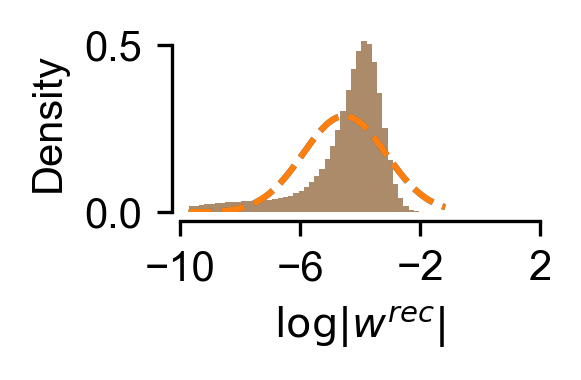

<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd/cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_6/epoch_ckpts/model_6.pt


/tmp/ipykernel_301027/2235757639.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),


x_lims are (np.float64(-10.01), np.float64(2.0))


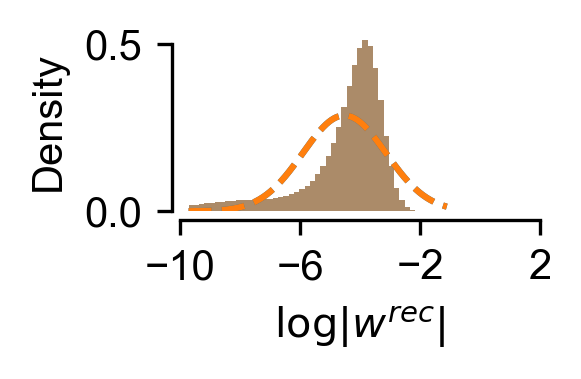

<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd/cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_7/epoch_ckpts/model_6.pt


/tmp/ipykernel_301027/2235757639.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),


x_lims are (np.float64(-10.01), np.float64(2.0))


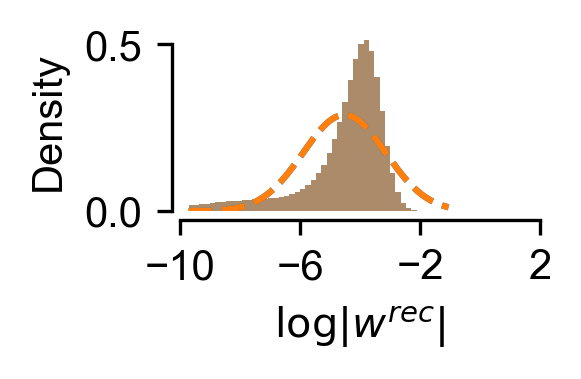

<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd/cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_8/epoch_ckpts/model_6.pt


/tmp/ipykernel_301027/2235757639.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),


x_lims are (np.float64(-10.01), np.float64(2.0))


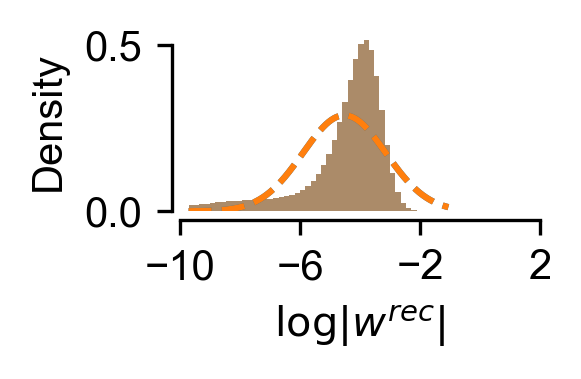

<class 'matplotlib.figure.Figure'>
/network/projects/_groups/linclab_users/eg/modcog/pingsheng_rebuttal/exp8_final_combined_with_cgd/cgd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_9/epoch_ckpts/model_6.pt


/tmp/ipykernel_301027/2235757639.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cgd_ckpt = torch.load(get_checkpoint_name(cgd_exp_results, seed, epoch_idx),


x_lims are (np.float64(-10.01), np.float64(2.0))


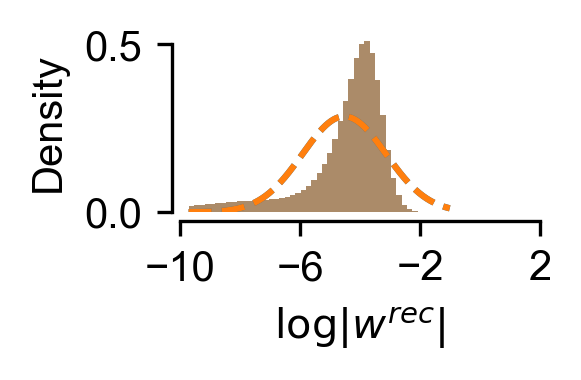

In [16]:
cgd_exp_results = results_dict.cgd_log_normal

fig, cgd_arr_all = plot_weight_hists(cgd_exp_results, cgd_key="rnn.weight_hh", epoch_idx=6, 
                  zero_th=6e-5, log_weights=True, log_y_scale=False, kde=False, stat='density',
                 gaussian_approx=True, xlims_step=(-10, 2, 4))  # 1e-5 for log weights

fig.savefig("figs/fig1/1e_ln_weights_hists.pdf", bbox_inches="tight", transparent=True)
# save the results data for later plotting again
import pickle
with open("plot_data/1e_ln_weights_hists_data.pkl", "wb") as f:
    pickle.dump(cgd_arr_all, f)

In [17]:
from scipy import stats

def z_score_arr(arr, axis=0):
    """axis 0 to z-score each column seperately"""
    mean = np.mean(arr, axis=axis)
    std = np.std(arr, axis=axis)
    return (arr - mean) / std

cgd_arr_z = []
for cgd_arr in cgd_arr_all:
    cgd_arr_z.append(z_score_arr(cgd_arr, axis=0))

cgd_stat = np.zeros(len(cgd_arr_all))

for seed in range(len(cgd_arr_all)):
    res_cgd = stats.kstest(cgd_arr_z[seed], stats.norm.cdf)
    
    print(f'seed {seed}')
    print(f'cSGD\n{res_cgd}')
    
    cgd_stat[seed] = res_cgd.statistic

seed 0
cSGD
KstestResult(statistic=np.float64(0.1525884242962594), pvalue=np.float64(0.0), statistic_location=np.float32(-0.06312523), statistic_sign=np.int8(-1))
seed 1
cSGD
KstestResult(statistic=np.float64(0.1529089706374917), pvalue=np.float64(0.0), statistic_location=np.float32(-0.056399886), statistic_sign=np.int8(-1))
seed 2
cSGD
KstestResult(statistic=np.float64(0.1524156428168857), pvalue=np.float64(0.0), statistic_location=np.float32(-0.06467015), statistic_sign=np.int8(-1))
seed 3
cSGD
KstestResult(statistic=np.float64(0.15381033048014975), pvalue=np.float64(0.0), statistic_location=np.float32(-0.062452544), statistic_sign=np.int8(-1))
seed 4
cSGD
KstestResult(statistic=np.float64(0.15379312070277112), pvalue=np.float64(0.0), statistic_location=np.float32(-0.06034105), statistic_sign=np.int8(-1))


(5,)
0.15310329778671156 0.0005918577522905147


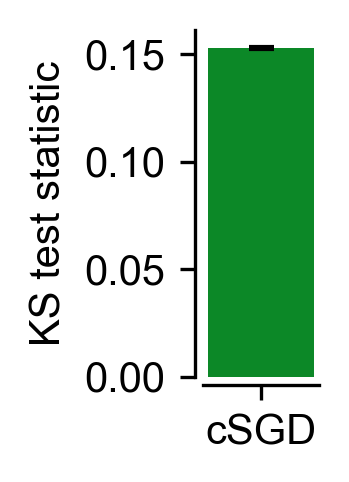

In [19]:
plt.figure(figsize=(0.5,1.5), dpi = 300)
exp_labels = ["cSGD"]
results_dict.cgd_log_normal.c = "#0c8827" # green
colours = [results_dict.cgd_log_normal.c]
key = "test_Dec_Acc"
means = []
std_devs = []
for array in [cgd_stat]:
    print(array.shape)
    means.append(array.mean())
    std_devs.append(array.std())
    print(array.mean(), array.std())

plt.bar(exp_labels, means, yerr=std_devs, color=colours, capsize=3,width=0.8 )
sns.despine(offset=2)

plt.ylabel("KS test statistic")

# plt.savefig("figs/fig1/1e_KS_cdf_ttest.pdf", bbox_inches="tight", transparent=True)
# save the results data for later plotting again
import pickle
with open("plot_data/1e_KS_cdf_ttest_data.pkl", "wb") as f:
    pickle.dump(cgd_stat, f)